# 2.3 — EVT-NeuralSSM

**Папка 2, подноутбук 3.** Grid search по гиперпараметрам EVT-NeuralSSM с историей по всем
метрикам и выбором метрики отбора → сохранение в `models/evt_ssm/hyperparams.json` →
финальное обучение чтением JSON с отслеживанием метрик.

## Окружение и данные

In [1]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Найти корень репозитория по наличию pyproject.toml вверх по дереву."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import display

from liquefaction_ai.viz import register_theme

register_theme()

# Если True — все фигуры сохраняются в results/figs (.html и .png)
SAVE_FIGS = True
DATA_DIR = REPO_ROOT / "data" / "demo_run"
MODELS_DIR = REPO_ROOT / "models"

import torch

from liquefaction_ai import load_population_artifact, prepare_benchmark_dataset, train_model
from liquefaction_ai.training import grid_search, write_hyperparams, read_hyperparams, save_trained_model
from liquefaction_ai.evaluation import METRICS, english_metric_table, metrics_catalog, subsample_split
from liquefaction_ai.viz import grid_search_dashboard, training_dashboard, lines

population, config = load_population_artifact(DATA_DIR)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
benchmark = prepare_benchmark_dataset(population, config, device)
static_dim = benchmark["train"]["static"].shape[1]
prefix_dim = benchmark["train"]["prefix_summary"].shape[1]
seq_dim = benchmark["train"]["seq_in"].shape[-1]

# Grid search выполняется на компактной подвыборке (для ранжирования гиперпараметров).
gs_train = subsample_split(benchmark["train"], 2000, config.seed)
gs_val = subsample_split(benchmark["val"], 600, config.seed + 1)


def show_grid_dashboard(res, grid, score, metric_keys, fig_id):
    """Построить дашборд grid search: по Y — метрики, по X — текст конфигурации."""
    info = METRICS[score]
    labels = {k: f"{METRICS[k].name} ({METRICS[k].units})" for k in metric_keys}
    fmts = {k: METRICS[k].fmt for k in metric_keys}
    return grid_search_dashboard(res, metric_keys, list(grid.keys()), score,
                                 metric_labels=labels, metric_fmts=fmts,
                                 lower_is_better=info.lower_is_better, target=info.target,
                                 save=SAVE_FIGS, fig_id=fig_id)

print("device:", device, "| dims static/prefix/seq:", static_dim, prefix_dim, seq_dim)
from liquefaction_ai.models import EVTNeuralSSM
from liquefaction_ai.evaluation import collect_outputs

device: cpu | dims static/prefix/seq: 34 6 5


## Каталог метрик

Все метрики качества определены с подробными описаниями в `liquefaction_ai.evaluation.metrics`
(`METRICS`) и импортируются в ноутбук. **Метрику отбора лучших гиперпараметров можно выбрать**
через переменную `SELECTION_METRIC` ниже.

In [2]:
display(metrics_catalog())

,Metric,Name,Units,Direction,Description
0,val_loss,Validation loss,–,lower is better,Mean validation value of the model's training ...
1,Traj_RMSE,Trajectory RMSE,–,lower is better,Root-mean-square error of the predicted pore-p...
2,Traj_MAE,Trajectory MAE,–,lower is better,Mean absolute error of the predicted PPR(N) tr...
3,Traj_MSE,Trajectory MSE,–,lower is better,Mean squared error of the predicted PPR(N) tra...
4,N_liq_MAE,MAE of N_liq,cycles,lower is better,Censored mean absolute error of the predicted ...
5,AUROC,AUROC,–,higher is better,Area under the ROC curve for liquefaction-risk...
6,AUPRC,AUPRC,–,higher is better,Area under the precision–recall curve; classif...
7,Brier,Brier score,–,lower is better,Mean squared error of the predicted liquefacti...
8,ECE,Expected calibration error,–,lower is better,Average absolute gap between predicted confide...
9,Coverage_90,90% interval coverage,–,target ≈ 0.9,Empirical fraction of true PPR values that fal...


## Шаг 1. Grid search и сохранение гиперпараметров

Selection metric: Traj_RMSE | best: {'hidden_dim': 128}


,hidden_dim,val_loss,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,AUROC,AUPRC,Brier,...,Interval width@90%,Coverage@95%,Interval width@95%,Calibration error,Trajectory NLL,Trajectory CRPS,CRR-curve RMSE,N_CRR_test,N_CRR_objects,Produces CRR
0,128,-0.7422,194.8965,543.1317,0.5146,0.6263,118.0,0.9923,0.9988,0.0753,...,0.5114,0.8824,0.6093,0.0590,-0.1532,0.1045,0.1384,96.0,1.0,1.0
1,96,-0.5380,188.4488,544.2143,0.4222,0.5308,118.0,0.9814,0.9969,0.0758,...,0.5038,0.8409,0.6003,0.1001,0.0228,0.1128,0.0784,96.0,1.0,1.0


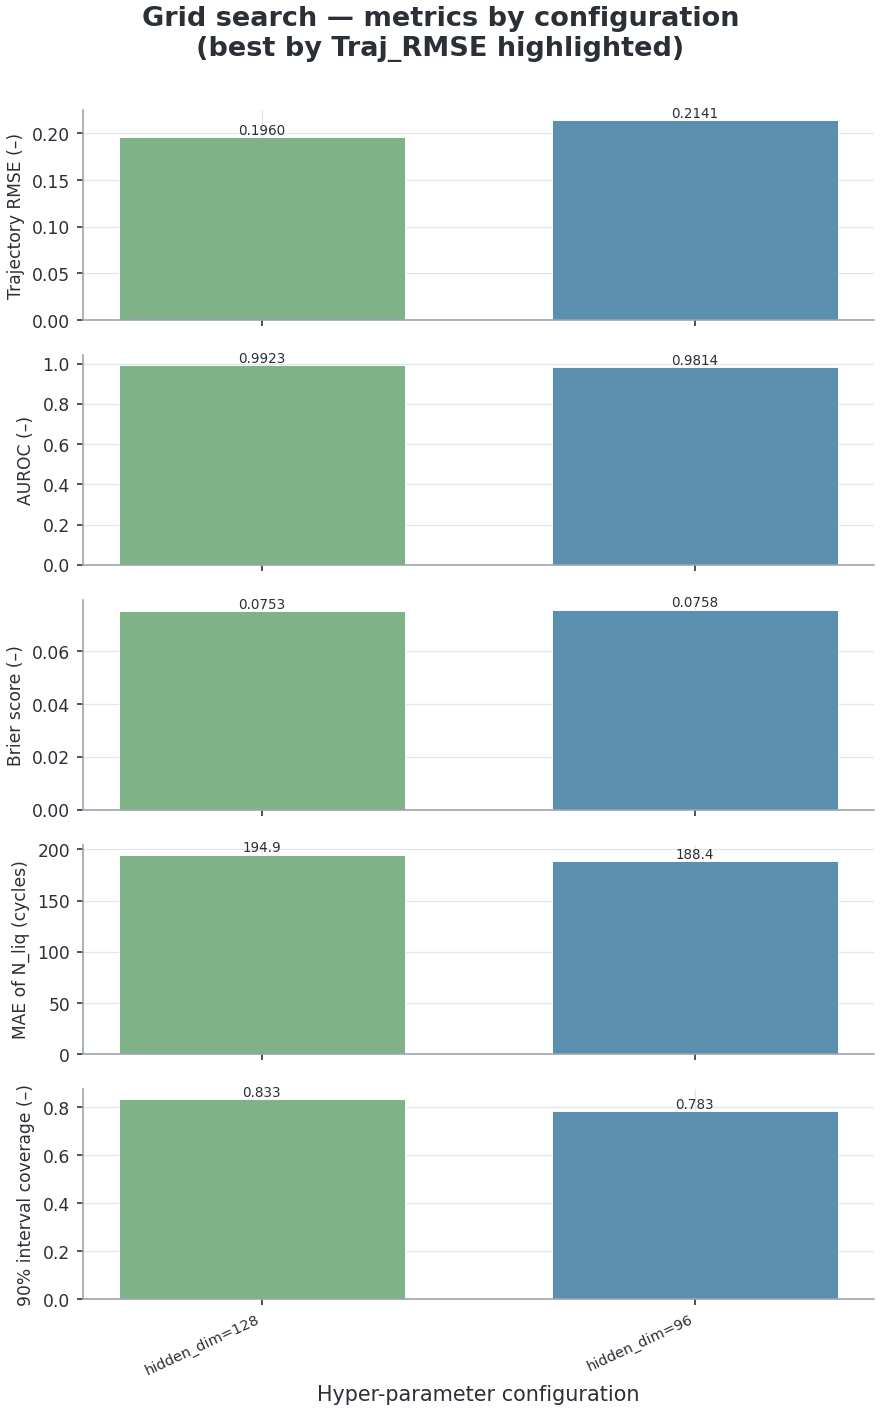

In [3]:
# >>> Метрика, по которой grid search выбирает лучшие гиперпараметры <<<
SELECTION_METRIC = "Traj_RMSE"   # например: "Traj_RMSE", "Brier", "AUROC", "N_liq_MAE", "val_loss"
DASHBOARD_METRICS = ["Traj_RMSE", "AUROC", "Brier", "N_liq_MAE", "Coverage_90"]

fixed = dict(static_dim=static_dim, prefix_dim=prefix_dim, seq_dim=seq_dim, seq_len=config.seq_len,
             prefix_len=config.prefix_len, max_cycle_reference=config.max_cycle_reference,
             use_trigger_head=True, structured_post_event=True, use_crr_damage=True, integrator="euler",
             liq_threshold=config.liq_threshold)
grid = {"hidden_dim": [96, 128]}
res, best = grid_search(lambda p: EVTNeuralSSM(**fixed, **p), grid, gs_train, gs_val,
                        config, device, search_epochs=2, score_metric=SELECTION_METRIC)
print("Selection metric:", SELECTION_METRIC, "| best:", best)
display(english_metric_table(res).round(4))
write_hyperparams(MODELS_DIR, "evt_ssm", {"model_type": "EVTNeuralSSM", "display_name": "EVT-NeuralSSM",
                  "model_kwargs": {**fixed, **best},
                  "search": {"grid": grid, "score_metric": SELECTION_METRIC, "best": best}})
show_grid_dashboard(res, grid, SELECTION_METRIC, DASHBOARD_METRICS, "2_3_grid_search").show()

## Шаг 2. Финальное обучение по сохранённым гиперпараметрам

In [4]:
from liquefaction_ai.evaluation import compute_metrics, fit_interval_scale
hp = read_hyperparams(MODELS_DIR, "evt_ssm")
# Best-of-seeds: модель чувствительна к инициализации — выбираем лучшую по ВАЛИДАЦИИ (без утечки теста)
best_model, best_history, best_val = None, None, float("inf")
for seed in [0, 1, 2]:
    torch.manual_seed(seed)
    cand = EVTNeuralSSM(**hp["model_kwargs"]).to(device)
    cand, hist = train_model(cand, benchmark["train"], benchmark["val"], epochs=config.physics_epochs,
                             model_name=f"EVT-NeuralSSM (seed {seed})", config=config, device=device,
                             track_metrics=True, scheduler="cosine")
    vr, _ = compute_metrics("val", collect_outputs(cand, benchmark["val"], config, device), benchmark["val"], config)
    print(f"seed {seed}: val Traj_RMSE = {vr['Traj_RMSE']:.4f}")
    if vr["Traj_RMSE"] < best_val:
        best_val, best_model, best_history = vr["Traj_RMSE"], cand, hist
model, history = best_model, best_history
# Пост-hoc конформная калибровка интервалов на валидации
calib_scale = fit_interval_scale(model, benchmark["val"], config, device, level=0.90)
save_trained_model(model, MODELS_DIR, "evt_ssm", {**hp, "epochs": config.physics_epochs,
                   "learning_rate": config.learning_rate, "weight_decay": config.weight_decay,
                   "batch_size": config.batch_size, "calib_scale": calib_scale}, history)
print("saved:", MODELS_DIR / "evt_ssm", "| best val RMSE:", round(best_val, 4), "| conformal s:", round(calib_scale, 2))

[EVT-NeuralSSM (seed 0)] эпоха 01 | обучение=4.5384 | валидация=0.6192 | val_AUROC=0.983 | val_RMSE=0.2795


[EVT-NeuralSSM (seed 0)] эпоха 02 | обучение=1.4464 | валидация=-0.3940 | val_AUROC=0.994 | val_RMSE=0.2255


[EVT-NeuralSSM (seed 0)] эпоха 03 | обучение=-0.6176 | валидация=-0.8914 | val_AUROC=0.991 | val_RMSE=0.2011


[EVT-NeuralSSM (seed 0)] эпоха 04 | обучение=-1.0016 | валидация=-1.2564 | val_AUROC=0.990 | val_RMSE=0.1480


[EVT-NeuralSSM (seed 0)] эпоха 05 | обучение=-1.1679 | валидация=-1.3198 | val_AUROC=0.991 | val_RMSE=0.1450


...

[EVT-NeuralSSM (seed 2)] эпоха 03 | обучение=-0.6940 | валидация=-1.0673 | val_AUROC=0.986 | val_RMSE=0.1694


[EVT-NeuralSSM (seed 2)] эпоха 04 | обучение=-1.0799 | валидация=-1.2547 | val_AUROC=0.990 | val_RMSE=0.1576


[EVT-NeuralSSM (seed 2)] эпоха 05 | обучение=-1.2694 | валидация=-1.3373 | val_AUROC=0.992 | val_RMSE=0.1563


[EVT-NeuralSSM (seed 2)] эпоха 06 | обучение=-1.3592 | валидация=-1.3696 | val_AUROC=0.992 | val_RMSE=0.1570


seed 2: val Traj_RMSE = 0.1570
saved: /Users/nikita/Desktop/projects/liquefaction-ai/models/evt_ssm | best val RMSE: 0.1394 | conformal s: 0.65


## Кривые обучения с метриками

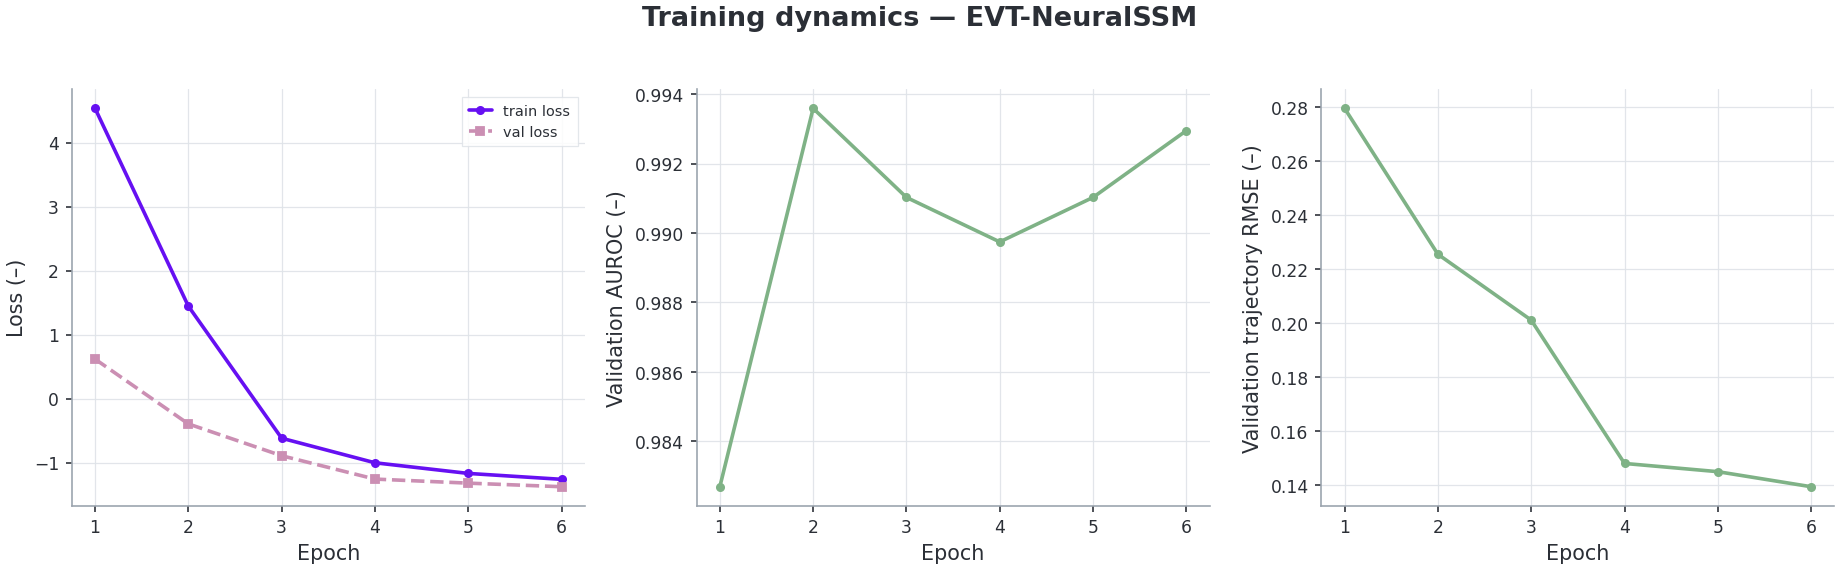

In [5]:
training_dashboard(history, title="Training dynamics — EVT-NeuralSSM", model_color="#6610f2",
                   save=SAVE_FIGS, fig_id="2_3_training_dashboard").show()

## Предпросмотр активации события

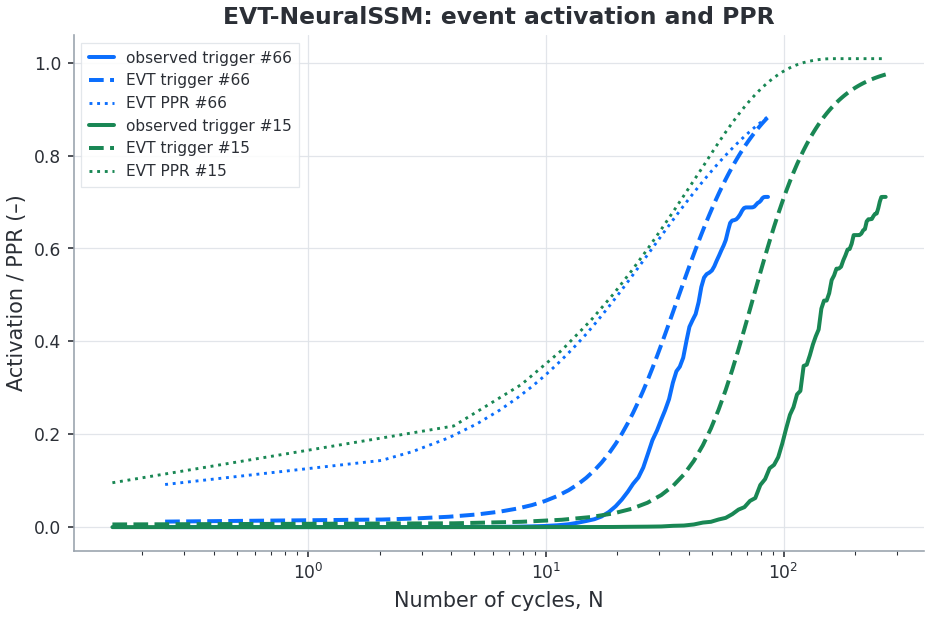

In [6]:
test = benchmark["test"]
outputs = collect_outputs(model, test, config, device)
cycles = test["cycles"].cpu().numpy(); g_true = (test["g_true"] if "g_true" in test else test["g_obs"]).cpu().numpy()  # реальные данные: наблюдаемый триггер
g_pred = outputs["g"]; r_pred = outputs["traj_mean"]; tm = test["meta"].reset_index(drop=True)
pick = tm[tm["liq_label"] == 1].sort_values("PPR_max_true", ascending=False).head(2).index.tolist()
series = []
for k, idx in enumerate(pick):
    col = ["#0b6efd", "#198754"][k]
    series.append({"x": cycles[idx], "y": g_true[idx], "name": f"observed trigger #{idx}", "color": col})
    series.append({"x": cycles[idx], "y": g_pred[idx], "name": f"EVT trigger #{idx}", "color": col, "dash": "dash"})
    series.append({"x": cycles[idx], "y": r_pred[idx], "name": f"EVT PPR #{idx}", "color": col, "dash": "dot", "width": 1.6})
lines(series, title="EVT-NeuralSSM: event activation and PPR", xlabel="Number of cycles, N",
      ylabel="Activation / PPR (–)", logx=True, save=SAVE_FIGS, fig_id="2_3_event_activation").show()

## Итог

EVT-NeuralSSM подобрана grid search (выбор метрики), обучена и сохранена. Дальше — **папка 3: метрики**.